Step 1/4: Data Preprocessing (IMS Prediction)
------------------------------------------------------------

Loading image features...
Spectral PCA completed: 6 components retained (fixed)
Image PCA completed: 186 components retained, cumulative variance ratio: 0.9503

Step 2/4: Fused Model Training (Fixed Best Params)
------------------------------------------------------------
Selected image PC indices (0-based): [3, 4, 6, 8, 29]
Selected PC variance ratios: [np.float64(0.0468), np.float64(0.0415), np.float64(0.0299), np.float64(0.0208), np.float64(0.0055)]
Cumulative variance ratio: 0.1445

Fused Model Performance Metrics:
[Train] R²: 0.946374 | MAE: 0.028754 | MRE: 0.031680 | RMSE: 0.037031
[Val] R²: 0.890416 | MAE: 0.036876 | MRE: 0.041734 | RMSE: 0.048395
[Test] R²: 0.867561 | MAE: 0.038212 | MRE: 0.042572 | RMSE: 0.046894
Train-Val Gap: 0.055958 | Train-Test Gap: 0.078813 | Valid: True

Comparison with Pure Spectral Baseline:
Baseline Test R²: 0.815157 | Fused Test R²: 0.867561
I

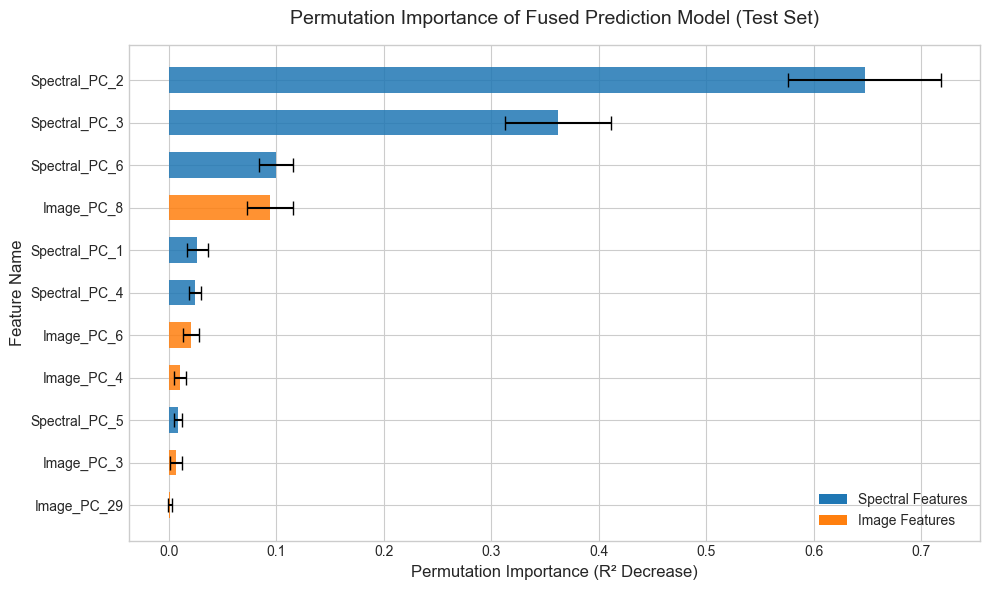


All results saved to: Image_Feature_K_Selection_Results_IMS_Tuned.xlsx


In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

np.random.seed(42)
random.seed(42)

def build_reg_model(params):
    return RandomForestRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )

def mean_relative_error(y_true, y_pred):
    mask = y_true != 0
    if np.sum(mask) == 0:
        return 0.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mre = mean_relative_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'mae': mae, 'mse': mse, 'rmse': rmse, 'mre': mre, 'r2': r2}

GAP_THRESHOLD = 0.15

print("=" * 60)
print("Step 1/4: Data Preprocessing (IMS Prediction)")
print("-" * 60)

pattern = pd.read_csv('4-pattern2.csv', header=None, encoding='utf-8-sig').values.astype('float64')
pattern = np.where(np.isinf(pattern), np.nan, pattern)
mean_val = np.nanmean(pattern) if not np.isnan(np.nanmean(pattern)) else 0
pattern = np.nan_to_num(pattern, nan=mean_val)

min_vals = np.min(pattern, axis=0)
max_vals = np.max(pattern, axis=0)
range_vals = np.where(max_vals - min_vals == 0, 1, max_vals - min_vals)
pattern_normalized = (pattern - min_vals) / range_vals
scaler_spectral = StandardScaler()
pattern_scaled = scaler_spectral.fit_transform(pattern_normalized)

print("\nLoading image features...")
image_features = pd.read_csv('image_features_mobilenet_large.csv', header=None).values.astype('float64')
scaler_image = StandardScaler()
image_features_scaled = scaler_image.fit_transform(image_features)

label_data = pd.read_csv('label_rIMS2-2.csv', header=None, encoding='utf-8-sig').values.astype('float64')
groups = label_data[:, 0]
label_c = np.exp(label_data[:, 1])
total_samples = len(label_c)

unique_groups = np.unique(groups)
test_size_groups = int(0.2 * len(unique_groups))
train_groups, test_groups = train_test_split(
    unique_groups, test_size=test_size_groups, random_state=42
)
train_mask = np.isin(groups, train_groups)
test_mask = np.isin(groups, test_groups)
train_indices = np.where(train_mask)[0]
test_indices = np.where(test_mask)[0]

X_train_raw_spectral = pattern_scaled[train_mask]
X_test_raw_spectral = pattern_scaled[test_mask]
y_train = label_c[train_mask]
y_test = label_c[test_mask]

pca_spectral = PCA(n_components=6)
X_train_spectral_pca = pca_spectral.fit_transform(X_train_raw_spectral)
X_test_spectral_pca = pca_spectral.transform(X_test_raw_spectral)
print(f"Spectral PCA completed: 6 components retained (fixed)")

pca_image = PCA(n_components=0.95)
pattern_image_pca_full = pca_image.fit_transform(image_features_scaled)
image_pca_variance = pca_image.explained_variance_ratio_
print(f"Image PCA completed: {pca_image.n_components_} components retained, cumulative variance ratio: {np.sum(image_pca_variance):.4f}")

X_train_image_pca_full = pattern_image_pca_full[train_mask]
X_test_image_pca_full = pattern_image_pca_full[test_mask]

print("\n" + "=" * 60)
print("Step 2/4: Fused Model Training (Fixed Best Params)")
print("-" * 60)

best_params = {
    'max_depth': 30,
    'max_features': 'log2',
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'n_estimators': 300
}
selected_image_indices = [3, 4, 6, 8, 29]
k = len(selected_image_indices)

X_train_image_selected = X_train_image_pca_full[:, selected_image_indices]
X_test_image_selected = X_test_image_pca_full[:, selected_image_indices]

selected_variance = image_pca_variance[selected_image_indices]
cumulative_variance = np.sum(selected_variance)
print(f"Selected image PC indices (0-based): {selected_image_indices}")
print(f"Selected PC variance ratios: {[round(v, 4) for v in selected_variance]}")
print(f"Cumulative variance ratio: {cumulative_variance:.4f}")

X_train_fused = np.hstack([X_train_spectral_pca, X_train_image_selected])
X_test_fused = np.hstack([X_test_spectral_pca, X_test_image_selected])

X_tr, X_val, y_tr, y_val, tr_idx, val_idx = train_test_split(
    X_train_fused, y_train, train_indices, test_size=0.2, random_state=42
)

final_model = build_reg_model(best_params)
final_model.fit(X_tr, y_tr)

y_tr_pred = final_model.predict(X_tr)
y_val_pred = final_model.predict(X_val)
y_train_pred = final_model.predict(X_train_fused)
y_test_pred = final_model.predict(X_test_fused)

tr_metrics = calculate_metrics(y_tr, y_tr_pred)
val_metrics = calculate_metrics(y_val, y_val_pred)
train_metrics = calculate_metrics(y_train, y_train_pred)
test_metrics = calculate_metrics(y_test, y_test_pred)

train_val_gap = abs(train_metrics['r2'] - val_metrics['r2'])
train_test_gap = abs(train_metrics['r2'] - test_metrics['r2'])
is_valid = (train_val_gap < GAP_THRESHOLD) and (train_test_gap < GAP_THRESHOLD)

fused_result = {
    'K': k,
    'Selected_Image_PCs': str(selected_image_indices),
    'Cumulative_Variance_Ratio': round(cumulative_variance, 4),
    'Best_Params': str(best_params),
    'Train_R2': round(train_metrics['r2'], 6),
    'Train_MAE': round(train_metrics['mae'], 6),
    'Train_MSE': round(train_metrics['mse'], 6),
    'Train_MRE': round(train_metrics['mre'], 6),
    'Train_RMSE': round(train_metrics['rmse'], 6),
    'Val_R2': round(val_metrics['r2'], 6),
    'Val_MAE': round(val_metrics['mae'], 6),
    'Val_MSE': round(val_metrics['mse'], 6),
    'Val_MRE': round(val_metrics['mre'], 6),
    'Val_RMSE': round(val_metrics['rmse'], 6),
    'Test_R2': round(test_metrics['r2'], 6),
    'Test_MAE': round(test_metrics['mae'], 6),
    'Test_MSE': round(test_metrics['mse'], 6),
    'Test_MRE': round(test_metrics['mre'], 6),
    'Test_RMSE': round(test_metrics['rmse'], 6),
    'Train_Val_Gap': round(train_val_gap, 6),
    'Train_Test_Gap': round(train_test_gap, 6),
    'Is_Valid': is_valid
}

BASELINE_RESULT = {
    'Train_R2': 0.955400,
    'Train_MAE': 0.025571,
    'Train_MSE': 0.033771**2,
    'Train_MRE': 0.027807,
    'Train_RMSE': 0.033771,
    'Val_R2': 0.888840,
    'Val_MAE': 0.035958,
    'Val_MSE': 0.048742**2,
    'Val_MRE': 0.040099,
    'Val_RMSE': 0.048742,
    'Test_R2': 0.815157,
    'Test_MAE': 0.045478,
    'Test_MSE': 0.055400**2,
    'Test_MRE': 0.049687,
    'Test_RMSE': 0.055400,
    'Train_Val_Gap': 0.066560,
    'Train_Test_Gap': 0.140243,
    'Best_Params': 'Fixed 6 spectral PCA',
    'Is_Valid': True
}

print("\nFused Model Performance Metrics:")
print(f"[Train] R²: {fused_result['Train_R2']:.6f} | MAE: {fused_result['Train_MAE']:.6f} | MRE: {fused_result['Train_MRE']:.6f} | RMSE: {fused_result['Train_RMSE']:.6f}")
print(f"[Val] R²: {fused_result['Val_R2']:.6f} | MAE: {fused_result['Val_MAE']:.6f} | MRE: {fused_result['Val_MRE']:.6f} | RMSE: {fused_result['Val_RMSE']:.6f}")
print(f"[Test] R²: {fused_result['Test_R2']:.6f} | MAE: {fused_result['Test_MAE']:.6f} | MRE: {fused_result['Test_MRE']:.6f} | RMSE: {fused_result['Test_RMSE']:.6f}")
print(f"Train-Val Gap: {fused_result['Train_Val_Gap']:.6f} | Train-Test Gap: {fused_result['Train_Test_Gap']:.6f} | Valid: {fused_result['Is_Valid']}")

improvement_r2 = (fused_result['Test_R2'] - BASELINE_RESULT['Test_R2']) * 100
improvement_mae = (BASELINE_RESULT['Test_MAE'] - fused_result['Test_MAE']) / BASELINE_RESULT['Test_MAE'] * 100
improvement_mre = (BASELINE_RESULT['Test_MRE'] - fused_result['Test_MRE']) / BASELINE_RESULT['Test_MRE'] * 100
improvement_rmse = (BASELINE_RESULT['Test_RMSE'] - fused_result['Test_RMSE']) / BASELINE_RESULT['Test_RMSE'] * 100

print("\nComparison with Pure Spectral Baseline:")
print(f"Baseline Test R²: {BASELINE_RESULT['Test_R2']:.6f} | Fused Test R²: {fused_result['Test_R2']:.6f}")
print(f"Improvement: R² {improvement_r2:+.2f}% | MAE {improvement_mae:+.2f}% | MRE {improvement_mre:+.2f}% | RMSE {improvement_rmse:+.2f}%")

print("\n" + "=" * 60)
print("Step 3/4: Permutation Importance Analysis")
print("-" * 60)
print("Calculating permutation importance on test set (n_repeats=10)...")

perm_importance_result = permutation_importance(
    estimator=final_model,
    X=X_test_fused,
    y=y_test,
    scoring='r2',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

n_spectral = 6
feature_names = [f"Spectral_PC_{i+1}" for i in range(n_spectral)] + \
                [f"Image_PC_{idx}" for idx in selected_image_indices]

perm_importance_df = pd.DataFrame({
    'Feature_Name': feature_names,
    'Importance_Mean': perm_importance_result.importances_mean,
    'Importance_Std': perm_importance_result.importances_std
})
perm_importance_sorted = perm_importance_df.sort_values(
    by='Importance_Mean', ascending=False
).reset_index(drop=True)

print("\n=== All Features Permutation Importance (Ranked) ===")
print(perm_importance_sorted.to_string(index=False))

spectral_mask = perm_importance_df['Feature_Name'].str.startswith('Spectral')
image_mask = perm_importance_df['Feature_Name'].str.startswith('Image')

total_spectral = perm_importance_df.loc[spectral_mask, 'Importance_Mean'].sum()
total_image = perm_importance_df.loc[image_mask, 'Importance_Mean'].sum()
total_all = total_spectral + total_image

if total_all > 1e-8:
    spectral_ratio = (total_spectral / total_all) * 100
    image_ratio = (total_image / total_all) * 100
else:
    spectral_ratio = 0.0
    image_ratio = 0.0

category_summary = pd.DataFrame([
    {
        'Feature_Category': 'Spectral Features',
        'Feature_Count': n_spectral,
        'Total_Importance': round(total_spectral, 6),
        'Contribution_Ratio': f"{spectral_ratio:.2f}%"
    },
    {
        'Feature_Category': 'Image Features',
        'Feature_Count': k,
        'Total_Importance': round(total_image, 6),
        'Contribution_Ratio': f"{image_ratio:.2f}%"
    }
])

print("\n=== Feature Category Contribution Summary ===")
print(category_summary.to_string(index=False))
print(f"\nConclusion: Image features account for {image_ratio:.2f}% of total prediction contribution.")

print("\n" + "=" * 60)
print("Step 4/4: Permutation Importance Visualization")
print("-" * 60)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = perm_importance_sorted.sort_values('Importance_Mean', ascending=True)

bar_colors = ['#1f77b4' if 'Spectral' in name else '#ff7f0e' for name in plot_df['Feature_Name']]

ax.barh(
    y=plot_df['Feature_Name'],
    width=plot_df['Importance_Mean'],
    xerr=plot_df['Importance_Std'],
    color=bar_colors,
    capsize=5,
    alpha=0.85,
    height=0.6
)

ax.set_xlabel('Permutation Importance (R² Decrease)', fontsize=12, fontweight='medium')
ax.set_ylabel('Feature Name', fontsize=12, fontweight='medium')
ax.set_title('Permutation Importance of Fused Prediction Model (Test Set)', fontsize=14, pad=15, fontweight='medium')

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#1f77b4', label='Spectral Features'),
    Patch(facecolor='#ff7f0e', label='Image Features')
]
ax.legend(handles=legend_handles, loc='lower right', framealpha=0.9)

plt.tight_layout()

plt.savefig('permutation_importance.png', dpi=300, bbox_inches='tight')
print("Visualization saved as: permutation_importance.png (300 DPI)")
plt.show()

with pd.ExcelWriter('Image_Feature_K_Selection_Results_IMS_Tuned.xlsx', engine='openpyxl') as writer:
    pd.DataFrame([BASELINE_RESULT]).to_excel(writer, sheet_name='Spectral_Baseline', index=False)
    pd.DataFrame([fused_result]).to_excel(writer, sheet_name='Best_Fused_Result', index=False)
    perm_importance_sorted.to_excel(writer, sheet_name='Permutation_Importance', index=False)
    category_summary.to_excel(writer, sheet_name='Feature_Contribution_Summary', index=False)

print(f"\nAll results saved to: Image_Feature_K_Selection_Results_IMS_Tuned.xlsx")
print("=" * 60)